# Projeto

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.ensemble import RandomForestClassifier



In [7]:
data = pd.read_csv('/Bank-Churn.csv',index_col=0)
data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
RowNumber,,,,,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [8]:
print(data.columns.tolist())

['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']


In [9]:
data = data.drop(columns=['CustomerId','Surname'])

In [10]:
data.info()
display(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Complain            10000 non-null  int64  
 12  Satisfaction Score  10000 non-null  int64  
 13  Card Type           10000 non-null  object 
 14  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 1.2+ MB


,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


## Análise exploratória

In [11]:
data.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
90%,778.000000,53.000000,9.000000,149244.792000,2.000000,1.00000,1.000000,179674.704000,1.000000,1.000000,5.000000,921.000000
99%,850.000000,72.000000,10.000000,185967.985400,3.000000,1.00000,1.000000,198069.734500,1.000000,1.000000,5.000000,992.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


array([[<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>],
       [<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Satisfaction Score'}>],
       [<Axes: title={'center': 'Point Earned'}>, <Axes: >, <Axes: >]],
      dtype=object)

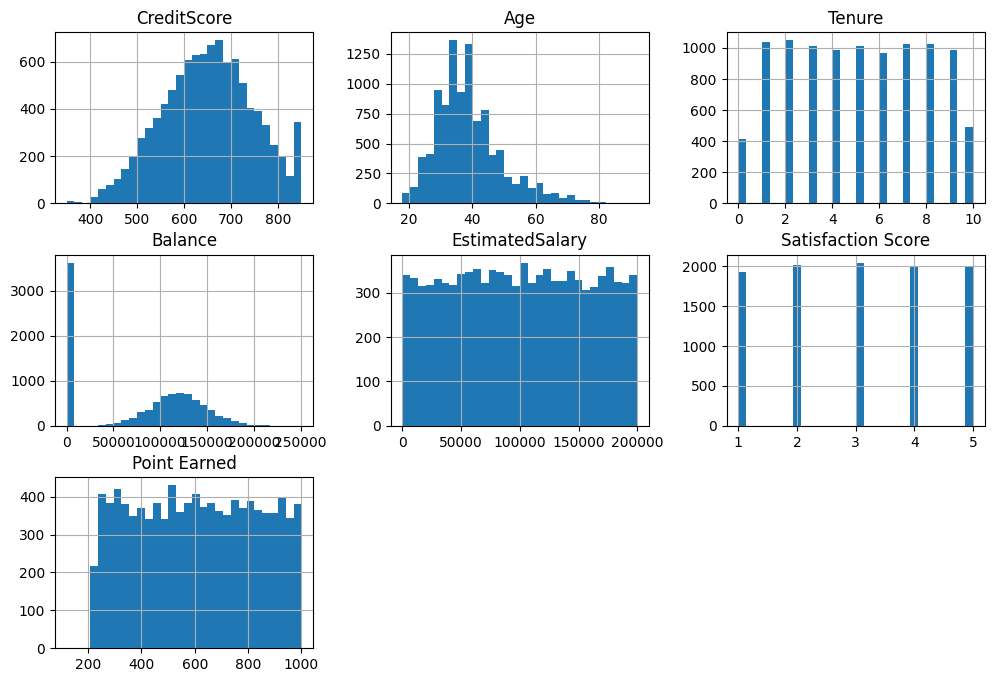

In [12]:
colunas = ['CreditScore','Age','Tenure','Balance','EstimatedSalary','Satisfaction Score','Point Earned']

data[colunas].hist(figsize=(12,8), bins=30)

In [13]:
data['Card Type'].unique()

array(['DIAMOND', 'GOLD', 'SILVER', 'PLATINUM'], dtype=object)

# Modelo Baseline com Perceptron

In [14]:
# separar x e y
target = 'Exited'
x = data.drop(columns=[target])
y = data[[target]]

In [15]:
# separar entre treino e teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=25)

In [16]:
print(x_train.shape)
print(x_test.shape)

(7000, 14)
(3000, 14)


In [17]:
display(data['Exited'].value_counts(normalize=True))
display(y_train.value_counts(normalize=True))
display(y_test.value_counts(normalize=True))

,proportion
Exited,
0,0.7962
1,0.2038


,proportion
Exited,
0,0.796143
1,0.203857


,proportion
Exited,
0,0.796333
1,0.203667


In [18]:
# colunas
num_cols = ['CreditScore','Age','Tenure','NumOfProducts',
            'EstimatedSalary','Satisfaction Score','Point Earned']

balance_col = ['Balance']

cat_cols = ['Geography','Gender']

ordinal_col = ['Card Type']


# ordem dos cartões
card_order = [['SILVER','GOLD','PLATINUM','DIAMOND']]


# pipeline para Balance (Yeo-Johnson + StandardScaler)
balance_pipeline = Pipeline([
    ('yeojohnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])


# transformações
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('balance', balance_pipeline, balance_col),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('ordinal', OrdinalEncoder(categories=card_order), ordinal_col)
    ],
    remainder='passthrough'
)


# pipeline final com Perceptron
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', Perceptron(random_state=25))
])

In [19]:
pipeline.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'NumOfProducts',
                                                   'EstimatedSalary',
                                                   'Satisfaction Score',
                                                   'Point Earned']),
                                                 ('balance',
                                                  Pipeline(steps=[('yeojohnson',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Balance']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['SILVER',
                                                                              'GOLD',
                                                                              'PLATINUM',
                                                                              'DIAMOND']]),
                                                  ['Card Type'])])),
                ('model', Perceptron(random_state=25))])

In [20]:
yhat_train = pipeline.predict(x_train)
yhat_test = pipeline.predict(x_test)

In [21]:
def evaluate(y_train, y_test, yhat_train, yhat_test):
  print('Treinamento')
  print(classification_report(y_train, yhat_train))
  print('*'*150)
  print('Teste')
  print(classification_report(y_test, yhat_test))

In [22]:
evaluate(y_train, y_test, yhat_train, yhat_test)

Treinamento
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5573
           1       0.99      1.00      0.99      1427

    accuracy                           1.00      7000
   macro avg       1.00      1.00      1.00      7000
weighted avg       1.00      1.00      1.00      7000

******************************************************************************************************************************************************
Teste
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2389
           1       1.00      0.99      0.99       611

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [23]:
#verificando coeficientes
coef = pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    "feature": pipeline.named_steps['preprocessing'].get_feature_names_out(),
    "coef": coef
})

coef_df.sort_values("coef", ascending=False)

,feature,coef
16,remainder__Complain,31.000000
6,num__Point Earned,2.291408
4,num__EstimatedSalary,0.865424
3,num__NumOfProducts,0.487959
1,num__Age,0.328808
5,num__Satisfaction Score,0.095582
2,num__Tenure,0.082553
14,remainder__HasCrCard,0.000000
13,ordinal__Card Type,0.000000
7,balance__Balance,-0.003582


Sem complaints

In [24]:
# remover a variável Complain
x_train_no_complain = x_train.drop(columns=['Complain'])
x_test_no_complain = x_test.drop(columns=['Complain'])

pipeline.fit(x_train_no_complain, y_train)

yhat_train_nc = pipeline.predict(x_train_no_complain)
yhat_test_nc = pipeline.predict(x_test_no_complain)

evaluate(y_train, y_test, yhat_train_nc, yhat_test_nc)

Treinamento
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      5573
           1       0.37      0.32      0.34      1427

    accuracy                           0.75      7000
   macro avg       0.60      0.59      0.59      7000
weighted avg       0.74      0.75      0.74      7000

******************************************************************************************************************************************************
Teste
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      2389
           1       0.39      0.34      0.36       611

    accuracy                           0.76      3000
   macro avg       0.61      0.60      0.61      3000
weighted avg       0.74      0.76      0.75      3000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Modelo com Árvore de Decisão

In [25]:
x_train_nc = x_train.drop(columns=['Complain'])
x_test_nc = x_test.drop(columns=['Complain'])

In [26]:
tree_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(random_state=25))
])

In [27]:
tree_pipeline.fit(x_train_nc, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'NumOfProducts',
                                                   'EstimatedSalary',
                                                   'Satisfaction Score',
                                                   'Point Earned']),
                                                 ('balance',
                                                  Pipeline(steps=[('yeojohnson',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Balance']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['SILVER',
                                                                              'GOLD',
                                                                              'PLATINUM',
                                                                              'DIAMOND']]),
                                                  ['Card Type'])])),
                ('model', DecisionTreeClassifier(random_state=25))])

In [28]:
yhat_train_tree = tree_pipeline.predict(x_train_nc)
yhat_test_tree = tree_pipeline.predict(x_test_nc)

In [29]:
evaluate(y_train, y_test, yhat_train_tree, yhat_test_tree)

Treinamento
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5573
           1       1.00      1.00      1.00      1427

    accuracy                           1.00      7000
   macro avg       1.00      1.00      1.00      7000
weighted avg       1.00      1.00      1.00      7000

******************************************************************************************************************************************************
Teste
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2389
           1       0.50      0.54      0.52       611

    accuracy                           0.80      3000
   macro avg       0.69      0.70      0.69      3000
weighted avg       0.80      0.80      0.80      3000



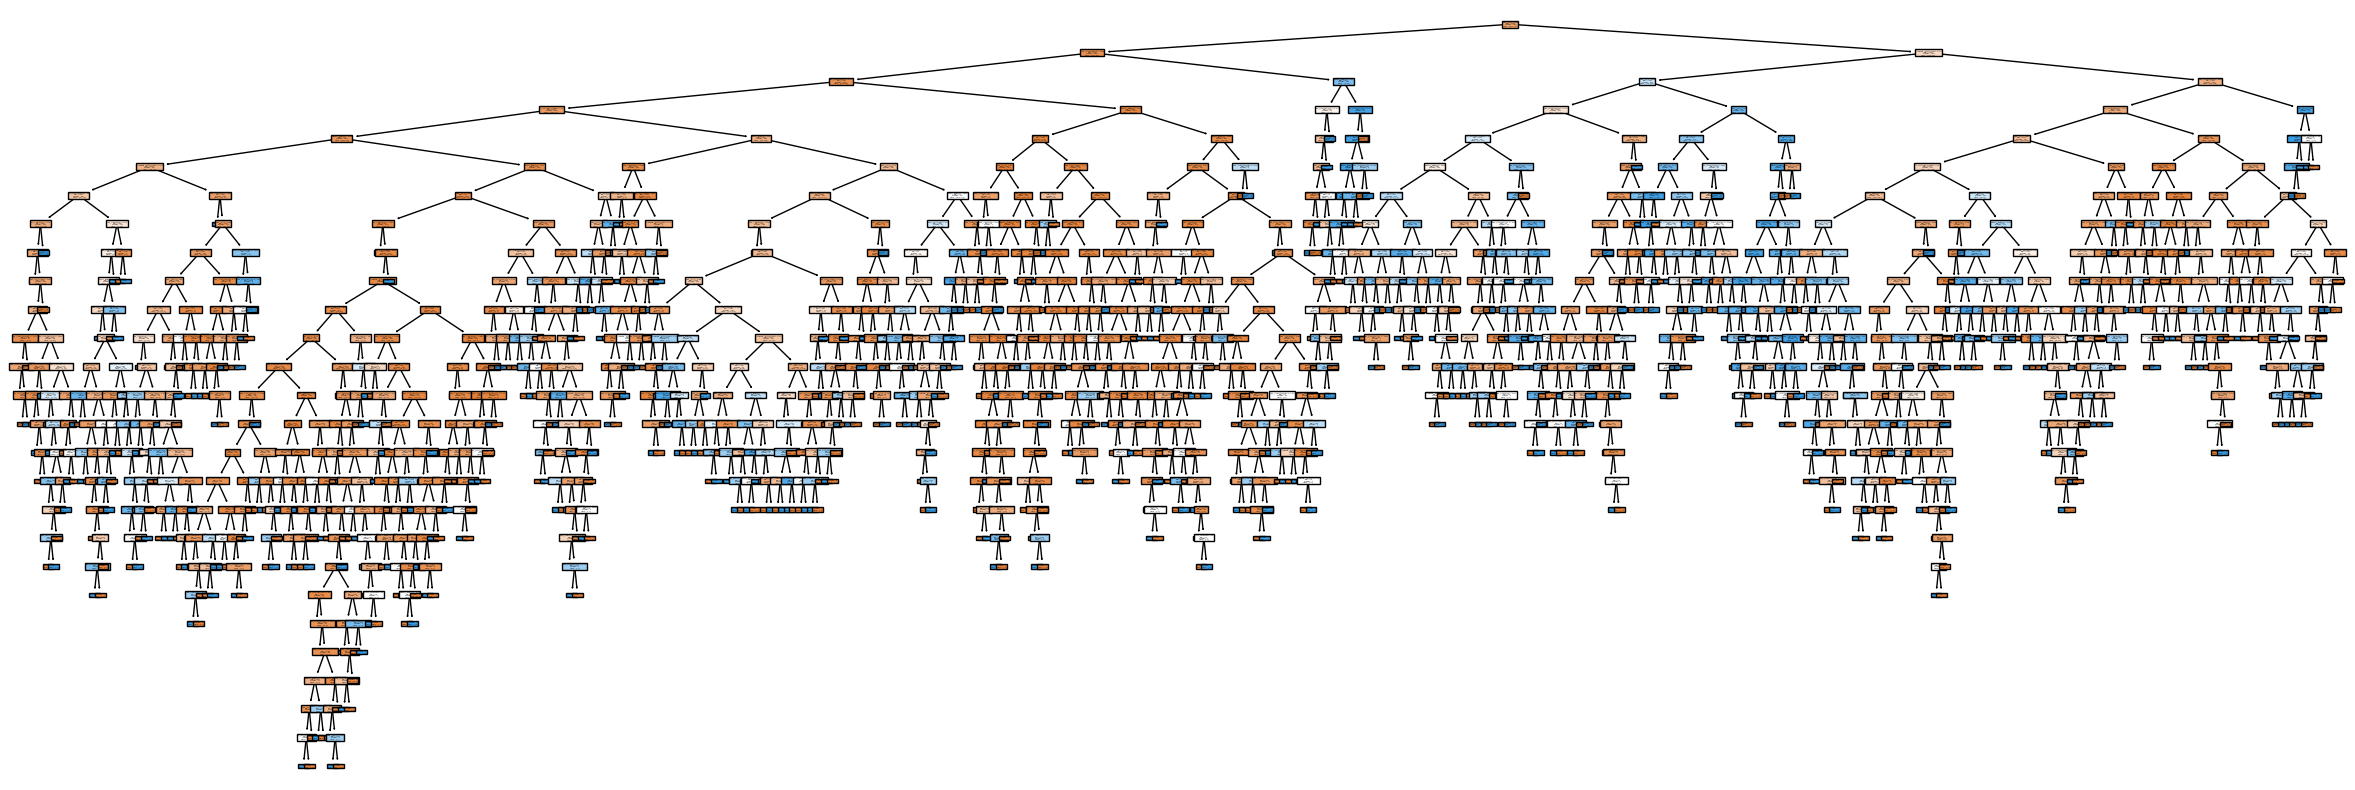

In [30]:
plt.figure(figsize=(30,10))

plot_tree(
    tree_pipeline.named_steps['model'],
    feature_names=tree_pipeline.named_steps['preprocessing'].get_feature_names_out(),
    filled=True
)

plt.show()

In [31]:
tree_pipeline.named_steps['model'].get_depth()

26

In [32]:
tree_pipeline.named_steps['model'].get_n_leaves()

np.int64(928)

# Validação cruzada e busca de hiperparâmetros

In [47]:
pipe_dt = Pipeline([
    ('preprocessing', preprocessor),
    ('dt', DecisionTreeClassifier(random_state=25))
])

In [48]:
params_grid = {
    'dt__criterion': ['gini', 'entropy', 'log_loss'],
    'dt__max_depth': [2, 5, 10, 20]
}

In [49]:
splitter = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=25
)

In [54]:
grid_search = GridSearchCV(
    estimator=pipe_dt,
    param_grid=params_grid,
    scoring='precision',
    cv=splitter,
    refit=True,
    verbose=10,
    error_score=0
)

In [55]:
grid_search.fit(x_train_nc, y_train)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV 1/10; 1/12] START dt__criterion=gini, dt__max_depth=2.......................
[CV 1/10; 1/12] END dt__criterion=gini, dt__max_depth=2;, score=0.663 total time=   0.1s
[CV 2/10; 1/12] START dt__criterion=gini, dt__max_depth=2.......................
[CV 2/10; 1/12] END dt__criterion=gini, dt__max_depth=2;, score=0.667 total time=   0.1s
[CV 3/10; 1/12] START dt__criterion=gini, dt__max_depth=2.......................
[CV 3/10; 1/12] END dt__criterion=gini, dt__max_depth=2;, score=0.522 total time=   0.1s
[CV 4/10; 1/12] START dt__criterion=gini, dt__max_depth=2.......................
[CV 4/10; 1/12] END dt__criterion=gini, dt__max_depth=2;, score=0.568 total time=   0.1s
[CV 5/10; 1/12] START dt__criterion=gini, dt__max_depth=2.......................
[CV 5/10; 1/12] END dt__criterion=gini, dt__max_depth=2;, score=0.693 total time=   0.1s
[CV 6/10; 1/12] START dt__criterion=gini, dt__max_depth=2.......................
[CV 6/

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=25, shuffle=True),
             error_score=0,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['CreditScore',
                                                                          'Age',
                                                                          'Tenure',
                                                                          'NumOfProducts',
                                                                          'EstimatedSalary',
                                                                          'Satisfaction '
                                                                          'Score',
                                                                          'Point '
                                                                          'Earned']),
                                                                        ('balance',
                                                                         Pipeline(steps=[('yeojoh...
                                                                                          StandardScaler())]),
                                                                         ['Balance']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Geography',
                                                                          'Gender']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['SILVER',
                                                                                                     'GOLD',
                                                                                                     'PLATINUM',
                                                                                                     'DIAMOND']]),
                                                                         ['Card '
                                                                          'Type'])])),
                                       ('dt',
                                        DecisionTreeClassifier(random_state=25))]),
             param_grid={'dt__criterion': ['gini', 'entropy', 'log_loss'],
                         'dt__max_depth': [2, 5, 10, 20]},
             scoring='precision', verbose=10)

In [56]:
grid_search.best_params_

{'dt__criterion': 'gini', 'dt__max_depth': 5}

In [57]:
grid_search.best_score_

np.float64(0.7696577868683354)

In [58]:
grid_search.best_estimator_.named_steps['dt'].get_depth()

5

In [59]:
grid_search.best_estimator_.named_steps['dt'].get_n_leaves()

np.int64(30)

In [63]:
precision_cv = []

for i in range(10):
    precision_fold = grid_search.cv_results_[f'split{i}_test_score'][
        np.where(grid_search.cv_results_['rank_test_score'] == 1)
    ][0]

    precision_cv.append(precision_fold)

precision_cv = np.array(precision_cv)

print("Precisão em cada fold:", precision_cv)
print("Média:", np.mean(precision_cv))
print("Desvio padrão:", np.std(precision_cv))

cv = np.std(precision_cv) * 100 / np.mean(precision_cv)
print("Coeficiente de variação:", cv)

ci_lower = np.mean(precision_cv) - 1.96 * np.std(precision_cv)/np.sqrt(10)
ci_upper = np.mean(precision_cv) + 1.96 * np.std(precision_cv)/np.sqrt(10)

print("Intervalo de confiança (95%):", ci_lower, "-", ci_upper)

Precisão em cada fold: [0.7        0.82692308 0.72463768 0.75409836 0.84126984 0.89090909
 0.67816092 0.76470588 0.82539683 0.69047619]
Média: 0.7696577868683354
Desvio padrão: 0.06928445363731954
Coeficiente de variação: 9.001981766368065
Intervalo de confiança (95%): 0.726714837601219 - 0.8126007361354518


In [66]:
yhat_train_opt = grid_search.best_estimator_.predict(x_train_nc)
yhat_test_opt = grid_search.best_estimator_.predict(x_test_nc)

print('Desempenho - Base de Treino')
print(classification_report(y_train, yhat_train_opt))

print('*'*150)

print('Desempenho - Base de Teste')
print(classification_report(y_test, yhat_test_opt))

Desempenho - Base de Treino
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      5573
           1       0.83      0.36      0.51      1427

    accuracy                           0.86      7000
   macro avg       0.85      0.67      0.71      7000
weighted avg       0.85      0.86      0.83      7000

******************************************************************************************************************************************************
Desempenho - Base de Teste
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2389
           1       0.81      0.41      0.54       611

    accuracy                           0.86      3000
   macro avg       0.84      0.69      0.73      3000
weighted avg       0.85      0.86      0.84      3000



# Modelo Ensemble: Random Forest

In [68]:
pipe_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('rf', RandomForestClassifier(random_state=25))
])

In [69]:
params_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [5, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

In [70]:
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=25)

In [77]:
grid_search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=params_grid_rf,
    scoring='precision',
    cv=splitter,
    refit=True,
    verbose=10,
    n_jobs=-1
)

In [78]:
grid_search_rf.fit(x_train_nc, y_train)

Fitting 10 folds for each of 24 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=25, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['CreditScore',
                                                                          'Age',
                                                                          'Tenure',
                                                                          'NumOfProducts',
                                                                          'EstimatedSalary',
                                                                          'Satisfaction '
                                                                          'Score',
                                                                          'Point '
                                                                          'Earned']),
                                                                        ('balance',
                                                                         Pipeline(steps=[('yeojohnson',
                                                                                          PowerTra...
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Geography',
                                                                          'Gender']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['SILVER',
                                                                                                     'GOLD',
                                                                                                     'PLATINUM',
                                                                                                     'DIAMOND']]),
                                                                         ['Card '
                                                                          'Type'])])),
                                       ('rf',
                                        RandomForestClassifier(random_state=25))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [5, 10, 20],
                         'rf__min_samples_leaf': [1, 2],
                         'rf__min_samples_split': [2, 5],
                         'rf__n_estimators': [100, 200]},
             scoring='precision', verbose=10)

In [79]:
grid_search_rf.best_params_

{'rf__max_depth': 5,
 'rf__min_samples_leaf': 1,
 'rf__min_samples_split': 5,
 'rf__n_estimators': 100}

In [80]:
yhat_train_rf = grid_search_rf.best_estimator_.predict(x_train_nc)
yhat_test_rf = grid_search_rf.best_estimator_.predict(x_test_nc)

print(classification_report(y_train, yhat_train_rf))
print(classification_report(y_test, yhat_test_rf))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92      5573
           1       0.89      0.34      0.49      1427

    accuracy                           0.86      7000
   macro avg       0.87      0.66      0.70      7000
weighted avg       0.86      0.86      0.83      7000

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2389
           1       0.85      0.36      0.51       611

    accuracy                           0.86      3000
   macro avg       0.86      0.67      0.71      3000
weighted avg       0.86      0.86      0.83      3000



In [81]:
rf_model = grid_search_rf.best_estimator_.named_steps['rf']

features = preprocessor.get_feature_names_out()

importances = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importances

,Feature,Importance
1,num__Age,0.385478
3,num__NumOfProducts,0.317855
15,remainder__IsActiveMember,0.097123
7,balance__Balance,0.056073
9,cat__Geography_Germany,0.053040
0,num__CreditScore,0.022928
4,num__EstimatedSalary,0.011986
11,cat__Gender_Female,0.010698
6,num__Point Earned,0.010569
12,cat__Gender_Male,0.010085
